# Анализ финальной модели ER

Визуализация результатов обучения финальной модели (`06_train_final.py`).

Конфигурация из HPO:
- hidden_dim=128, edge_dim=128, num_gnn_layers=3, dropout=0.0, bidirectional=True
- lr=7.5e-4, weight_decay=0.0, margin=0.1
- Early stopping (patience=30, max_epochs=1000)

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("../output")

# Загрузка данных
with open(OUTPUT_DIR / "er_final_history.json") as f:
    history = json.load(f)

with open(OUTPUT_DIR / "er_final_metrics.json", encoding="utf-8") as f:
    metrics = json.load(f)

config = metrics["config"]
print("Конфигурация:")
for k, v in config.items():
    print(f"  {k}: {v}")

Конфигурация:
  hidden_dim: 128
  edge_dim: 128
  num_gnn_layers: 3
  dropout: 0.0
  bidirectional: True
  lr: 0.0007507349035904968
  margin: 0.1
  weight_decay: 0.0
  max_epochs: 1000
  patience: 30


## 1. Кривые обучения (Train / Val Loss)

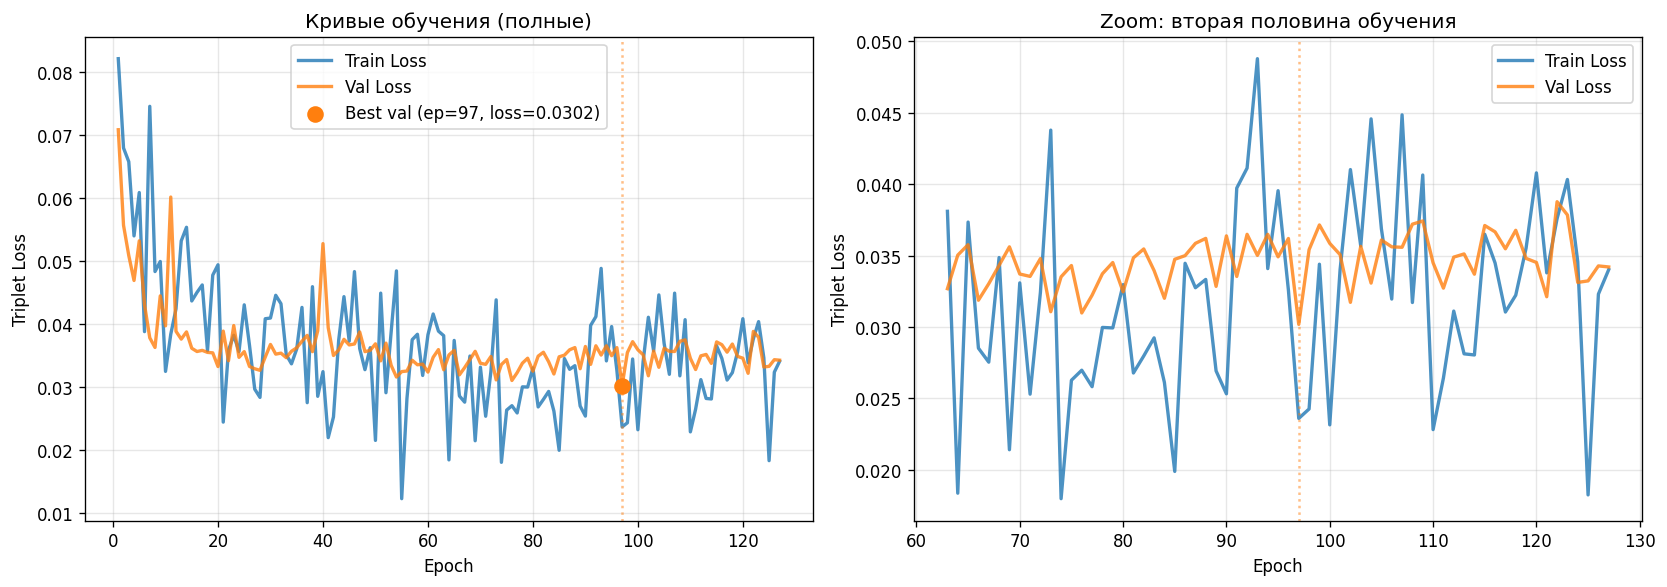

Всего эпох: 127
Final train loss: 0.0340
Best val loss: 0.0302 (epoch 97)
Final val loss: 0.0342
Эпох после best: 30 (patience=30)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Полная кривая ---
ax = axes[0]
train_loss = history.get("train_loss", [])
val_loss = history.get("val_loss", [])

best_ep, best_val = None, None

if train_loss:
    epochs = range(1, len(train_loss) + 1)
    ax.plot(epochs, train_loss, label="Train Loss", linewidth=2, alpha=0.8)
if val_loss:
    val_epochs = range(1, len(val_loss) + 1)
    ax.plot(val_epochs, val_loss, label="Val Loss", linewidth=2, alpha=0.8)
    best_ep = int(np.argmin(val_loss)) + 1
    best_val = min(val_loss)
    ax.axvline(best_ep, color="C1", ls=":", alpha=0.5)
    ax.scatter([best_ep], [best_val], color="C1", s=80, zorder=5,
               label=f"Best val (ep={best_ep}, loss={best_val:.4f})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Loss")
ax.set_title("Кривые обучения (полные)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Последние 50% эпох (zoom) ---
ax = axes[1]
if train_loss:
    half = max(len(train_loss) // 2, 1)
    ax.plot(range(half, len(train_loss) + 1), train_loss[half - 1:], label="Train Loss", linewidth=2, alpha=0.8)
if val_loss:
    half_v = max(len(val_loss) // 2, 1)
    ax.plot(range(half_v, len(val_loss) + 1), val_loss[half_v - 1:], label="Val Loss", linewidth=2, alpha=0.8)
    if best_ep:
        ax.axvline(best_ep, color="C1", ls=":", alpha=0.5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Loss")
ax.set_title("Zoom: вторая половина обучения")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_epochs = max(len(train_loss), len(val_loss))
print(f"Всего эпох: {n_epochs}")
if train_loss:
    print(f"Final train loss: {train_loss[-1]:.4f}")
if best_val is not None:
    print(f"Best val loss: {best_val:.4f} (epoch {best_ep})")
    print(f"Final val loss: {val_loss[-1]:.4f}")
    if len(val_loss) > best_ep:
        print(f"Эпох после best: {len(val_loss) - best_ep} (patience={config.get('patience', '?')})")

## 2. Скорость сходимости (val_loss по эпохам)

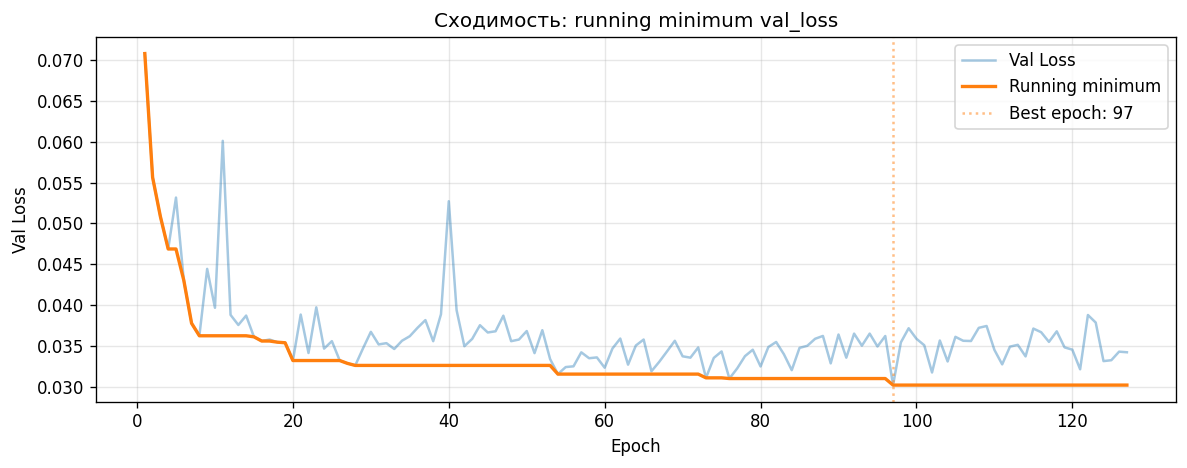

  50% улучшения к эпохе 4
  90% улучшения к эпохе 20
  95% улучшения к эпохе 54
  99% улучшения к эпохе 97


In [5]:
if val_loss:
    fig, ax = plt.subplots(figsize=(10, 4))
    running_min = np.minimum.accumulate(val_loss)
    ax.plot(range(1, len(val_loss) + 1), val_loss, alpha=0.4, label="Val Loss")
    ax.plot(range(1, len(val_loss) + 1), running_min, linewidth=2, label="Running minimum")
    ax.axvline(best_ep, color="C1", ls=":", alpha=0.5, label=f"Best epoch: {best_ep}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss")
    ax.set_title("Сходимость: running minimum val_loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Когда 90%, 95%, 99% улучшения достигнуто
    total_improvement = val_loss[0] - best_val
    if total_improvement > 0:
        for pct in [0.5, 0.9, 0.95, 0.99]:
            target = val_loss[0] - pct * total_improvement
            ep = next((i + 1 for i, v in enumerate(val_loss) if v <= target), len(val_loss))
            print(f"  {pct:.0%} улучшения к эпохе {ep}")

## 3. In-domain результаты

In [6]:
df_in = pd.DataFrame(metrics["in_domain"]["per_dataset"])
metric_cols = ["roc_auc", "avg_precision"]

if not df_in.empty:
    display(df_in.style
        .set_caption(f"In-domain: {len(df_in)} датасетов")
        .background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.4f}" for c in metric_cols})
    )
    for m in metric_cols:
        vals = df_in[m].dropna()
        print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")
else:
    print("Нет in-domain результатов")

,roc_auc,avg_precision,name
0,0.4698,0.2610,baby_products
1,0.8310,0.6470,beer
2,0.5334,0.2820,bikes
3,0.7420,0.8379,books1
4,0.5631,0.8593,books3
5,0.7274,0.5493,books4
6,0.9038,0.5708,books5
7,0.8567,0.7743,ebooks1
8,0.6865,0.4017,ebooks2
9,0.6260,0.4874,movies1


  roc_auc        : 0.7504 ± 0.1473
  avg_precision  : 0.6320 ± 0.2228


## 4. Cross-domain результаты

In [7]:
df_cross = pd.DataFrame(metrics["cross_domain"]["per_dataset"])

if not df_cross.empty:
    display(df_cross.style
        .set_caption(f"Cross-domain: {len(df_cross)} hold-out датасетов")
        .background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.4f}" for c in metric_cols})
    )
    for m in metric_cols:
        vals = df_cross[m].dropna()
        print(f"  {m:15s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}")
else:
    print("Нет cross-domain результатов")

,roc_auc,avg_precision,name
0,0.8914,0.9056,anime
1,0.7097,0.4906,books2
2,0.5883,0.2843,citations
3,0.6979,0.4055,electronics
4,0.6687,0.3796,restaurants3


  roc_auc        : 0.7112 ± 0.1113
  avg_precision  : 0.4931 ± 0.2420


## 5. ROC-AUC bar chart по датасетам

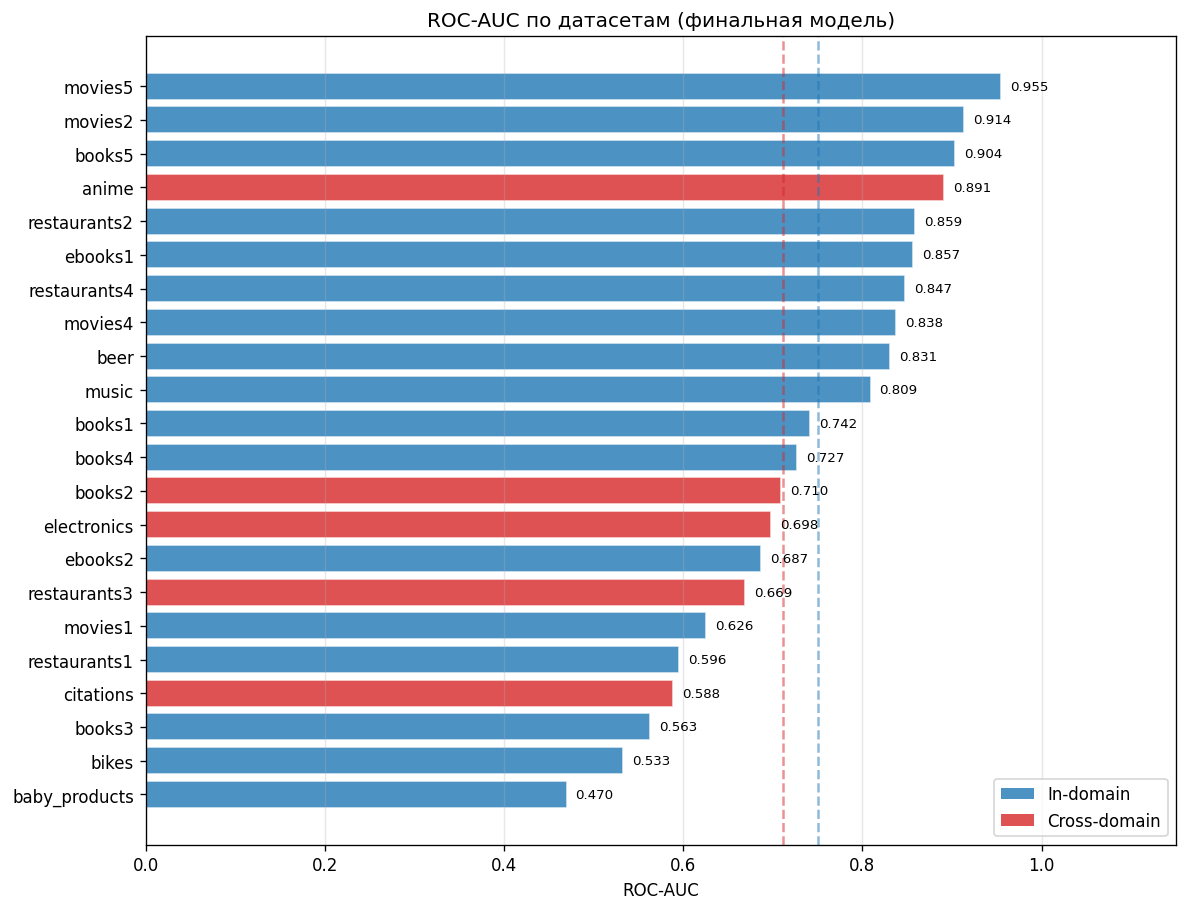

In [8]:
df_in["eval_type"] = "in-domain"
if not df_cross.empty:
    df_cross["eval_type"] = "cross-domain"
    df_all = pd.concat([df_in, df_cross], ignore_index=True)
else:
    df_all = df_in.copy()

df_all = df_all.sort_values("roc_auc", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_all) * 0.35)))
colors = ["C3" if et == "cross-domain" else "C0" for et in df_all["eval_type"]]
bars = ax.barh(df_all["name"], df_all["roc_auc"], color=colors, alpha=0.8, edgecolor="white")

for bar, val in zip(bars, df_all["roc_auc"]):
    if pd.notna(val):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

ax.set_xlabel("ROC-AUC")
ax.set_xlim(0, 1.15)
ax.set_title("ROC-AUC по датасетам (финальная модель)")
ax.axvline(df_in["roc_auc"].mean(), color="C0", ls="--", alpha=0.5,
           label=f"In-domain mean={df_in['roc_auc'].mean():.3f}")
if not df_cross.empty:
    ax.axvline(df_cross["roc_auc"].mean(), color="C3", ls="--", alpha=0.5,
               label=f"Cross-domain mean={df_cross['roc_auc'].mean():.3f}")

handles = [Patch(facecolor="C0", alpha=0.8, label="In-domain"),
           Patch(facecolor="C3", alpha=0.8, label="Cross-domain")]
ax.legend(handles=handles, loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 6. In-domain vs Cross-domain (boxplot)

/tmp/ipykernel_4016623/314100788.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
/tmp/ipykernel_4016623/314100788.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],


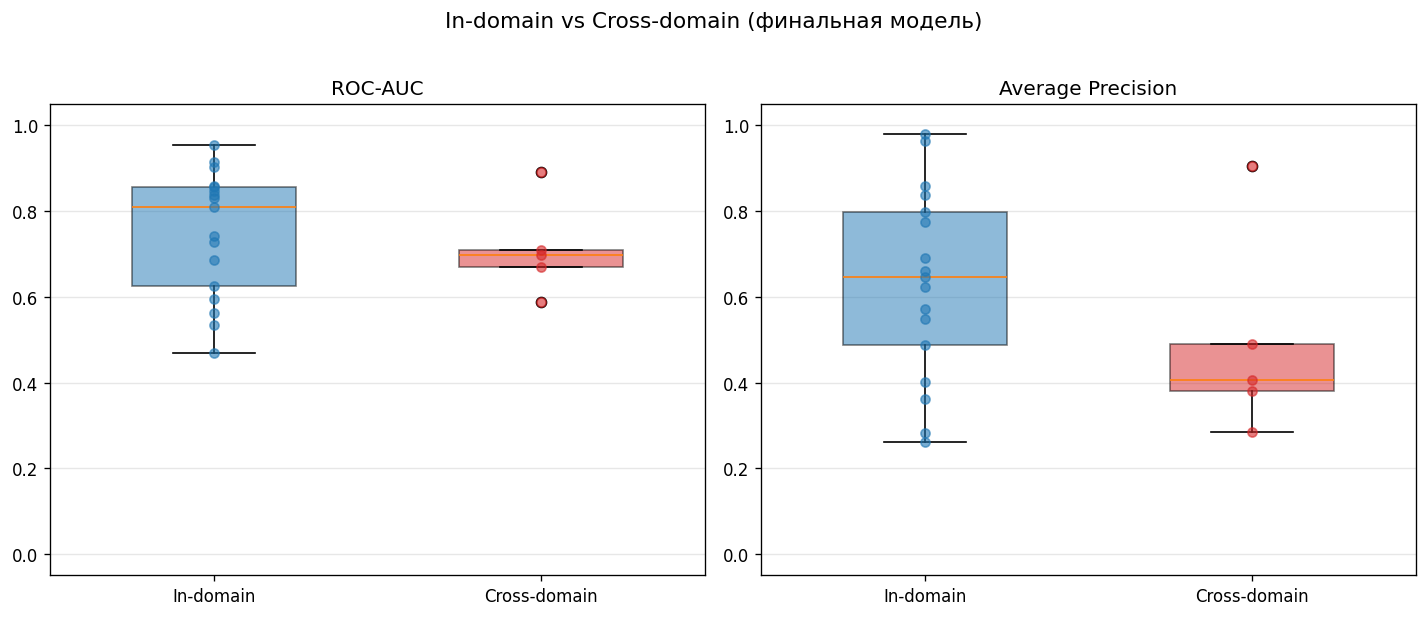

,Metric,In-domain,Cross-domain,Drop
0,ROC-AUC,0.7504,0.7112,0.0392
1,Avg Precision,0.6320,0.4931,0.1389


In [9]:
if not df_cross.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, metric, title in zip(axes, ["roc_auc", "avg_precision"],
                                       ["ROC-AUC", "Average Precision"]):
        in_vals = df_in[metric].dropna()
        cross_vals = df_cross[metric].dropna()

        bp = ax.boxplot([in_vals, cross_vals], labels=["In-domain", "Cross-domain"],
                        patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("C0")
        bp["boxes"][0].set_alpha(0.5)
        bp["boxes"][1].set_facecolor("C3")
        bp["boxes"][1].set_alpha(0.5)

        ax.scatter(np.ones(len(in_vals)), in_vals, alpha=0.6, s=30, zorder=5, color="C0")
        ax.scatter(np.ones(len(cross_vals)) * 2, cross_vals, alpha=0.6, s=30, zorder=5, color="C3")

        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle("In-domain vs Cross-domain (финальная модель)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    comparison = pd.DataFrame({
        "Metric": ["ROC-AUC", "Avg Precision"],
        "In-domain": [df_in["roc_auc"].mean(), df_in["avg_precision"].mean()],
        "Cross-domain": [df_cross["roc_auc"].mean(), df_cross["avg_precision"].mean()],
    })
    comparison["Drop"] = comparison["In-domain"] - comparison["Cross-domain"]
    display(comparison.style.format("{:.4f}", subset=["In-domain", "Cross-domain", "Drop"])
            .set_caption("Падение метрик на unseen доменах"))
else:
    print("Нет cross-domain данных для сравнения")

## 7. Сравнение с предыдущей моделью (до HPO)

In [10]:
old_path = OUTPUT_DIR / "er_results_multidataset.json"

if old_path.exists():
    with open(old_path, encoding="utf-8") as f:
        old = json.load(f)

    old_in = pd.DataFrame(old["in_domain_results"])
    old_cross = pd.DataFrame(old.get("cross_domain_results", []))

    cmp_data = {
        "Metric": ["In-domain ROC-AUC", "In-domain AP", "Cross-domain ROC-AUC", "Cross-domain AP"],
        "До HPO (50 эпох)": [
            old_in["roc_auc"].mean() if not old_in.empty else None,
            old_in["avg_precision"].mean() if not old_in.empty else None,
            old_cross["roc_auc"].mean() if not old_cross.empty else None,
            old_cross["avg_precision"].mean() if not old_cross.empty else None,
        ],
        "После HPO (финальная)": [
            metrics["in_domain"]["roc_auc"],
            metrics["in_domain"]["avg_precision"],
            metrics["cross_domain"]["roc_auc"],
            metrics["cross_domain"]["avg_precision"],
        ],
    }
    cmp = pd.DataFrame(cmp_data)
    cmp["Improvement"] = cmp["После HPO (финальная)"] - cmp["До HPO (50 эпох)"]

    display(cmp.style
        .format("{:.4f}", subset=["До HPO (50 эпох)", "После HPO (финальная)", "Improvement"], na_rep="—")
        .applymap(lambda v: "color: green" if isinstance(v, float) and v > 0 else 
                  "color: red" if isinstance(v, float) and v < 0 else "",
                  subset=["Improvement"])
        .set_caption("Сравнение: модель до HPO vs финальная модель")
    )
else:
    print("Файл предыдущей модели (er_results_multidataset.json) не найден — сравнение недоступно")

Файл предыдущей модели (er_results_multidataset.json) не найден — сравнение недоступно


## 8. Итоговая сводка

In [11]:
print("=" * 60)
print("ФИНАЛЬНАЯ МОДЕЛЬ — СВОДКА")
print("=" * 60)
print(f"Модель: output/er_model_hpo_best.pt")
print(f"Эпох обучения: {len(history.get('train_loss', []))}")
if val_loss:
    print(f"Best epoch: {best_ep} (val_loss={best_val:.4f})")
print()

print(f"In-domain:")
print(f"  ROC-AUC:          {metrics['in_domain']['roc_auc']:.4f}")
print(f"  Avg Precision:    {metrics['in_domain']['avg_precision']:.4f}")
print()
print(f"Cross-domain:")
print(f"  ROC-AUC:          {metrics['cross_domain']['roc_auc']:.4f}")
print(f"  Avg Precision:    {metrics['cross_domain']['avg_precision']:.4f}")

if not df_in.empty:
    print(f"\nХудшие in-domain (ROC-AUC < 0.6):")
    worst = df_in[df_in["roc_auc"] < 0.6]
    if len(worst) > 0:
        for _, row in worst.iterrows():
            print(f"  {row['name']:25s} AUC={row['roc_auc']:.4f}  AP={row['avg_precision']:.4f}")
    else:
        print("  Нет (все >= 0.6)")

print("=" * 60)

ФИНАЛЬНАЯ МОДЕЛЬ — СВОДКА
Модель: output/er_model_hpo_best.pt
Эпох обучения: 127
Best epoch: 97 (val_loss=0.0302)

In-domain:
  ROC-AUC:          0.7504
  Avg Precision:    0.6320

Cross-domain:
  ROC-AUC:          0.7112
  Avg Precision:    0.4931

Худшие in-domain (ROC-AUC < 0.6):
  baby_products             AUC=0.4698  AP=0.2610
  bikes                     AUC=0.5334  AP=0.2820
  books3                    AUC=0.5631  AP=0.8593
  restaurants1              AUC=0.5957  AP=0.3613
